# 🎭 Analyse de Sentiment — Bénin Insights

Ce notebook construit deux modèles d'analyse de sentiment sur les données GDELT du Bénin :

| Modèle | Type | Target | Source |
|--------|------|--------|--------|
| **Modèle 1** | Régression | Prédire la valeur numérique du tone (`AvgTone`) | Events |
| **Modèle 2** | Classification | Prédire le sentiment (positif / neutre / négatif) | Events |

**AvgTone** est le ton moyen lié à l'évenement évoqué dans un article. Ton moyen : -100 (très négatif) à +100 (très positif), 0 = neutre*

**Pipeline pour chaque modèle :**
1. Préparation des données (features, target, splits)
2. Entraînement (baseline + modèle principal)
3. Évaluation (métriques + visualisations)
4. Sauvegarde `.pkl` dans `models/sentiment_analysis/`

> **Note :** Cette version (v1) utilise les features numériques disponibles.
> Une v2 intégrant le NLP HuggingFace sur les textes d'articles est prévue.


## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path

# Modèles
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor, DummyClassifier

# Régression
from sklearn.linear_model import Ridge
from sklearn.ensemble import (GradientBoostingRegressor,
                               GradientBoostingClassifier,
                               RandomForestClassifier,
                               RandomForestRegressor)

# Classification
from sklearn.linear_model import LogisticRegression

# Métriques
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

# ── Dossier de sauvegarde des modèles ───────────────────────────────────────
MODELS_DIR = Path('..') / 'models' / 'sentiment_analysis'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"✅ Imports OK")
print(f"📁 Dossier modèles : {MODELS_DIR.resolve()}")

✅ Imports OK
📁 Dossier modèles : C:\Users\DELL latitude 5420\Documents\Hackathon_iSHEEROXDatacamp\models\sentiment_analysis


## 1. Chargement des données

In [2]:
# ── Chemins ──────────────────────────────────────────────────────────────────
EVENTS_PATH = Path('..') / 'data' / 'processed' / 'events_cleaned.csv'
GKG_PATH    = Path('..') / 'data' / 'processed' / 'gkg_cleaned.csv'

# Option Colab (décommenter si nécessaire)
# from google.colab import drive; drive.mount('/content/drive')
# EVENTS_PATH = '/content/drive/MyDrive/hackathon/data/processed/events_cleaned.csv'
# GKG_PATH    = '/content/drive/MyDrive/hackathon/data/processed/gkg_cleaned.csv'

df_events = pd.read_csv(EVENTS_PATH, low_memory=False)
df_gkg    = pd.read_csv(GKG_PATH,    low_memory=False)

print(f"✅ Events : {df_events.shape[0]:,} lignes × {df_events.shape[1]} colonnes")
print(f"✅ GKG    : {df_gkg.shape[0]:,} lignes × {df_gkg.shape[1]} colonnes")

# ── Parsing date Events ───────────────────────────────────────────────────────
df_events['EventDate'] = pd.to_datetime(
    df_events['SQLDATE'].astype(str), format='%Y%m%d', errors='coerce'
)
df_events['month'] = df_events['EventDate'].dt.to_period('M')

# ── Parsing V2Tone GKG ────────────────────────────────────────────────────────
tone_parsed = (
    df_gkg['V2Tone'].astype(str)
    .str.split(',', expand=True)
    .iloc[:, :6]
)
tone_parsed.columns = ['tone_global','tone_positif','tone_negatif',
                        'polarite','activite','auto_ref']
df_gkg[tone_parsed.columns] = tone_parsed.apply(pd.to_numeric, errors='coerce')

df_gkg['datetime'] = pd.to_datetime(
    df_gkg['Date'].astype(str).str[:8], format='%Y%m%d', errors='coerce'
)

print(f"\n📅 Période Events : {df_events['EventDate'].min().date()} → {df_events['EventDate'].max().date()}")
print(f"📅 Période GKG    : {df_gkg['datetime'].min().date()} → {df_gkg['datetime'].max().date()}")


✅ Events : 27,317 lignes × 46 colonnes
✅ GKG    : 24,453 lignes × 9 colonnes

📅 Période Events : 2025-01-01 → 2025-12-31
📅 Période GKG    : 2025-01-01 → 2025-12-31


## 2. Préparation des données

**Source principale :** Dataset Events pour les deux modèles.
Le GKG enrichit la cible de classification via son `tone_global`.

**Features retenues :**

| Feature | Description | Justification |
|---------|-------------|---------------|
| `GoldsteinScale` | Impact théorique sur la stabilité (-10 à +10) | Fort signal de conflictualité |
| `NumMentions` | Nombre total de mentions médias | Proxy d'importance |
| `NumSources` | Nombre de sources distinctes | Proxy de diversité |
| `NumArticles` | Nombre d'articles | Proxy de couverture |
| `QuadClass` | Grande catégorie CAMEO (1-4) | Signal structurel |
| `EventRootCode` | Code CAMEO racine (1-20) | Type d'action |

**Target Modèle 1 — Régression :** `AvgTone` (valeur continue)
**Target Modèle 2 — Classification :** `sentiment_label` (positif / neutre / négatif)


In [3]:
# ── Définition des features ───────────────────────────────────────────────────
FEATURES = ['GoldsteinScale', 'NumMentions', 'NumSources',
            'NumArticles', 'QuadClass', 'EventRootCode']
TARGET_REG  = 'AvgTone'
TARGET_CLF  = 'sentiment_label'

# Vérifier la disponibilité des colonnes
features_ok = [f for f in FEATURES if f in df_events.columns]
print(f"Features disponibles : {features_ok}")
print(f"Features manquantes  : {[f for f in FEATURES if f not in df_events.columns]}")

# ── Construction du dataset ML ───────────────────────────────────────────────
df_ml = df_events[features_ok + [TARGET_REG]].dropna().copy()

# Normaliser EventRootCode en entier
df_ml['EventRootCode'] = (
    pd.to_numeric(df_ml['EventRootCode'], errors='coerce')
    .fillna(0).astype(int)
)

# Supprimer outliers sur NumMentions (top 1%)
q99 = df_ml['NumMentions'].quantile(0.99)
df_ml = df_ml[df_ml['NumMentions'] <= q99].copy()

print(f"\nDataset ML final : {len(df_ml):,} événements")
print(f"\nStatistiques de la target AvgTone :")
print(df_ml[TARGET_REG].describe().round(3).to_string())


Features disponibles : ['GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'QuadClass', 'EventRootCode']
Features manquantes  : []

Dataset ML final : 27,268 événements

Statistiques de la target AvgTone :
count    27268.000
mean        -1.373
std          4.467
min        -18.519
25%         -4.457
50%         -1.310
75%          1.838
max         19.481


Distribution des classes de sentiment :
  négatif    : 12,023 ( 44.1%)  ██████████████████████
  neutre     :  8,720 ( 32.0%)  ████████████████
  positif    :  6,525 ( 23.9%)  ███████████


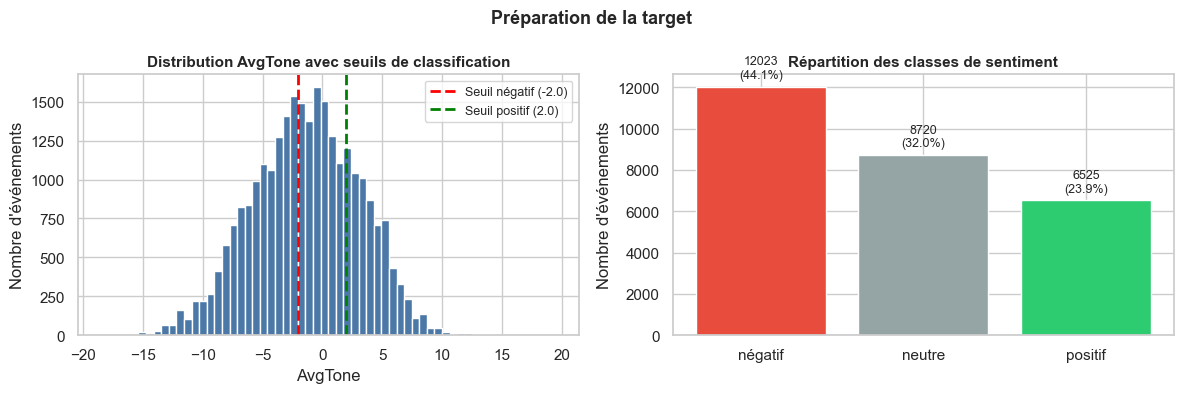


📌 Note : les seuils -2.0 / 2.0 peuvent être ajustés
   selon la distribution réelle observée ci-dessus.


In [4]:
# ── Création de la target de classification ──────────────────────────────────
# Seuils basés sur la distribution de AvgTone
# Valeurs typiques GDELT : -10 à +10, moyenne autour de -2 à 0

SEUIL_NEG = -2.0   # en dessous → négatif
SEUIL_POS =  2.0   # au dessus  → positif

def label_sentiment(tone):
    if tone < SEUIL_NEG:
        return 'négatif'
    elif tone > SEUIL_POS:
        return 'positif'
    else:
        return 'neutre'

df_ml[TARGET_CLF] = df_ml[TARGET_REG].apply(label_sentiment)

# Distribution des classes
dist = df_ml[TARGET_CLF].value_counts()
dist_pct = (dist / len(df_ml) * 100).round(1)

print("Distribution des classes de sentiment :")
for label in dist.index:
    bar = '█' * int(dist_pct[label] / 2)
    print(f"  {label:10s} : {dist[label]:6,} ({dist_pct[label]:5.1f}%)  {bar}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution AvgTone avec seuils
df_ml[TARGET_REG].hist(bins=60, ax=axes[0], color='#4C78A8', edgecolor='white')
axes[0].axvline(SEUIL_NEG, color='red',   linestyle='--', linewidth=2,
                label=f'Seuil négatif ({SEUIL_NEG})')
axes[0].axvline(SEUIL_POS, color='green', linestyle='--', linewidth=2,
                label=f'Seuil positif ({SEUIL_POS})')
axes[0].set_title('Distribution AvgTone avec seuils de classification',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('AvgTone')
axes[0].set_ylabel("Nombre d'événements")
axes[0].legend(fontsize=9)

# Répartition des classes
colors_sent = {'négatif':'#e74c3c', 'neutre':'#95a5a6', 'positif':'#2ecc71'}
bar_colors  = [colors_sent[l] for l in dist.index]
axes[1].bar(dist.index, dist.values, color=bar_colors)
axes[1].set_title('Répartition des classes de sentiment', fontsize=11, fontweight='bold')
axes[1].set_ylabel("Nombre d'événements")
axes[1].bar_label(axes[1].containers[0],
                  labels=[f"{v}\n({p}%)" for v,p in zip(dist.values, dist_pct.values)],
                  padding=4, fontsize=9)

plt.suptitle('Préparation de la target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📌 Note : les seuils {SEUIL_NEG} / {SEUIL_POS} peuvent être ajustés")
print(f"   selon la distribution réelle observée ci-dessus.")


In [5]:
# ── Splits train / test ───────────────────────────────────────────────────────
FEATURES_FINAL = [f for f in features_ok if f in df_ml.columns]

X = df_ml[FEATURES_FINAL]
y_reg = df_ml[TARGET_REG]
y_clf = df_ml[TARGET_CLF]

X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2, random_state=42,
    stratify=y_clf   # stratifier sur la classification pour équilibrer
)

print(f"Train : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nFeatures utilisées : {FEATURES_FINAL}")
print(f"\nDistribution classes — Train :")
print(yc_train.value_counts().to_string())
print(f"\nDistribution classes — Test :")
print(yc_test.value_counts().to_string())


Train : 21,814 (80%)
Test  : 5,454  (20%)

Features utilisées : ['GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'QuadClass', 'EventRootCode']

Distribution classes — Train :
sentiment_label
négatif    9618
neutre     6976
positif    5220

Distribution classes — Test :
sentiment_label
négatif    2405
neutre     1744
positif    1305


## 3. Modèle 1 — Régression : prédire AvgTone

**Objectif :** Prédire la valeur numérique du tone médiatique d'un événement
à partir de ses caractéristiques structurelles.

**Pipeline :**
- **Baseline** : DummyRegressor (prédit toujours la moyenne) — point de référence
- **Ridge** : régression linéaire régularisée — modèle simple interprétable
- **Gradient Boosting** : modèle ensembliste — modèle principal

**Métriques d'évaluation :**
- `MAE` (Mean Absolute Error) — erreur moyenne en unités de tone
- `RMSE` (Root Mean Squared Error) — pénalise les grosses erreurs
- `R²` — part de variance expliquée (1.0 = parfait, 0 = pas mieux que la moyenne)


In [6]:
print("=" * 60)
print("MODÈLE 1 — RÉGRESSION AVGTONE")
print("=" * 60)

# ── Définition des modèles ────────────────────────────────────────────────────
reg_models = {
    'Baseline (moyenne)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  DummyRegressor(strategy='mean'))
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingRegressor(
            n_estimators=200, max_depth=4,
            learning_rate=0.05, random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(
            n_estimators=100, max_depth=8,
            random_state=42, n_jobs=-1
        ))
    ]),
}

# ── Entraînement et évaluation ────────────────────────────────────────────────
reg_results = {}

for name, pipeline in reg_models.items():
    pipeline.fit(X_train, yr_train)
    y_pred = pipeline.predict(X_test)

    mae  = mean_absolute_error(yr_test, y_pred)
    rmse = np.sqrt(mean_squared_error(yr_test, y_pred))
    r2   = r2_score(yr_test, y_pred)

    reg_results[name] = {
        'pipeline': pipeline,
        'y_pred':   y_pred,
        'MAE':      mae,
        'RMSE':     rmse,
        'R2':       r2,
    }
    print(f"  {name:25s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

# Identifier le meilleur modèle (R² max hors baseline)
best_reg_name = max(
    {k:v for k,v in reg_results.items() if 'Baseline' not in k},
    key=lambda k: reg_results[k]['R2']
)
print(f"\n🏆 Meilleur modèle (R²) : {best_reg_name}")


MODÈLE 1 — RÉGRESSION AVGTONE
  Baseline (moyenne)        → MAE=3.570  RMSE=4.405  R²=-0.000
  Ridge                     → MAE=3.187  RMSE=4.007  R²=0.173
  Gradient Boosting         → MAE=3.076  RMSE=3.902  R²=0.215
  Random Forest             → MAE=3.087  RMSE=3.923  R²=0.207

🏆 Meilleur modèle (R²) : Gradient Boosting


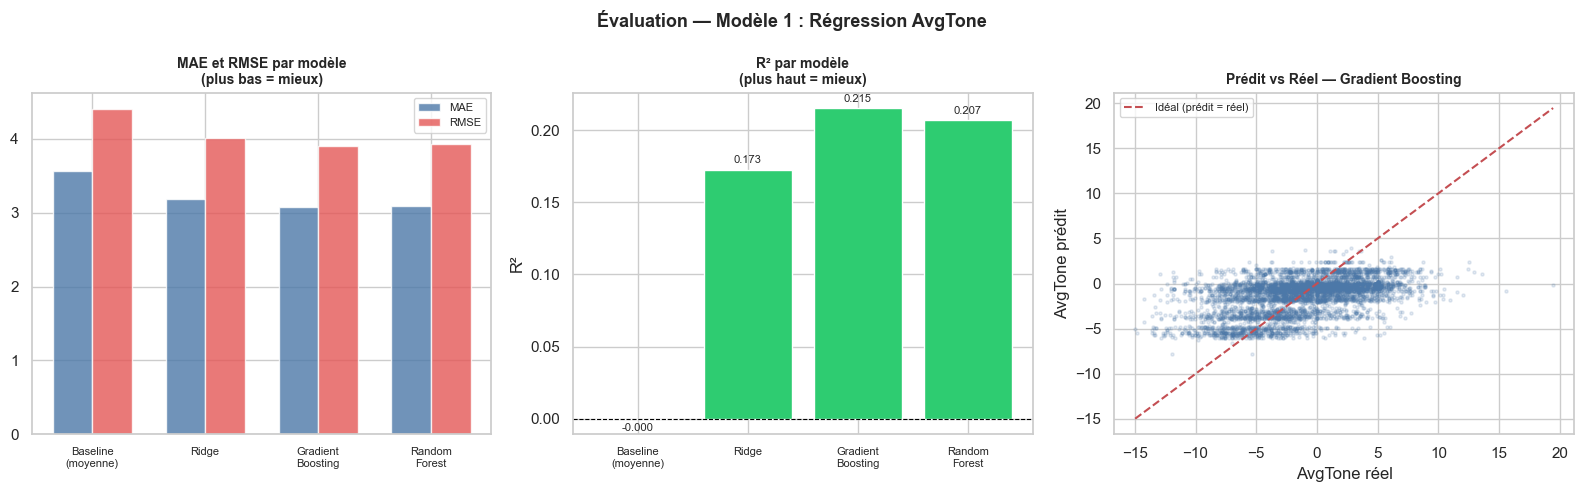


📌 Interprétation :
   Le meilleur modèle (Gradient Boosting) explique 21.5% de la variance du tone.
   Erreur moyenne de prédiction : ±3.08 points de tone.
   Un R² faible est attendu : le tone dépend aussi du contenu textuel
   des articles, non disponible dans nos features numériques.


In [7]:
# ── Visualisation des résultats de régression ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Comparaison des métriques ─────────────────────────────────────────────────
names  = list(reg_results.keys())
maes   = [reg_results[n]['MAE']  for n in names]
rmses  = [reg_results[n]['RMSE'] for n in names]
r2s    = [reg_results[n]['R2']   for n in names]

x = np.arange(len(names))
w = 0.35
axes[0].bar(x - w/2, maes,  w, label='MAE',  color='#4C78A8', alpha=0.8)
axes[0].bar(x + w/2, rmses, w, label='RMSE', color='#E45756', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
axes[0].set_title('MAE et RMSE par modèle\n(plus bas = mieux)', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].bar(names, r2s,
            color=['#bdc3c7' if 'Baseline' in n else '#2ecc71' for n in names])
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('R² par modèle\n(plus haut = mieux)', fontsize=10, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=3, fontsize=8)

# ── Prédit vs Réel pour le meilleur modèle ────────────────────────────────────
y_pred_best = reg_results[best_reg_name]['y_pred']
axes[2].scatter(yr_test, y_pred_best, alpha=0.15, s=5, color='#4C78A8')
lims = [min(yr_test.min(), y_pred_best.min()),
        max(yr_test.max(), y_pred_best.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1.5, label='Idéal (prédit = réel)')
axes[2].set_title(f'Prédit vs Réel — {best_reg_name}', fontsize=10, fontweight='bold')
axes[2].set_xlabel('AvgTone réel')
axes[2].set_ylabel('AvgTone prédit')
axes[2].legend(fontsize=8)

plt.suptitle('Évaluation — Modèle 1 : Régression AvgTone',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_r2  = reg_results[best_reg_name]['R2']
best_mae = reg_results[best_reg_name]['MAE']
print(f"\n📌 Interprétation :")
print(f"   Le meilleur modèle ({best_reg_name}) explique {best_r2*100:.1f}% de la variance du tone.")
print(f"   Erreur moyenne de prédiction : ±{best_mae:.2f} points de tone.")
print(f"   Un R² faible est attendu : le tone dépend aussi du contenu textuel")
print(f"   des articles, non disponible dans nos features numériques.")


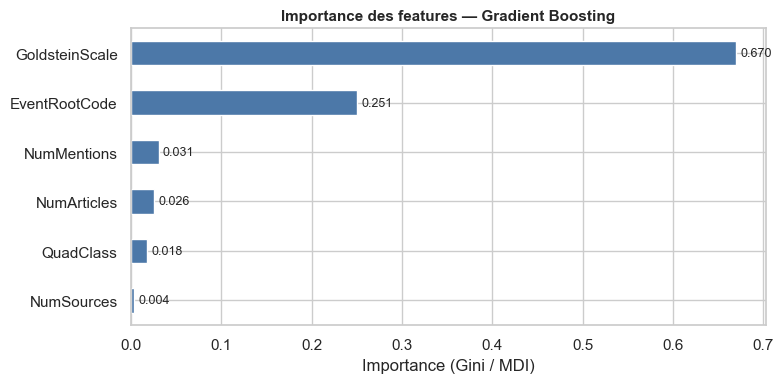

In [9]:
# ── Importance des features — meilleur modèle ─────────────────────────────────
best_reg_pipeline = reg_results[best_reg_name]['pipeline']
model_step = best_reg_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    feat_imp = pd.Series(
        model_step.feature_importances_,
        index=FEATURES_FINAL
    ).sort_values()

    fig, ax = plt.subplots(figsize=(8, 4))
    feat_imp.plot(kind='barh', ax=ax, color='#4C78A8')
    ax.set_title(f'Importance des features — {best_reg_name}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance (Gini / MDI)')
    ax.bar_label(ax.containers[0], fmt='%.3f', padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

    top_feat = feat_imp.index[-1]

elif hasattr(model_step, 'coef_'):
    coef = pd.Series(
        model_step.coef_, index=FEATURES_FINAL
    ).sort_values()
    print("Coefficients Ridge :")
    print(coef.round(4).to_string())


### Feature la plus prédictive du tone : GoldsteinScale
   C'est cohérent : Le modèle de classificcation des évenement dans le notebook ml_classification.ipynb nous avait montrer que le score d'impact théorique (GoldsteinScale) d'un évenement est directement lié à la nature positive/négative de l'événement.

In [14]:
# ── Sauvegarde du modèle de régression ───────────────────────────────────────
reg_save_path = MODELS_DIR / 'regression_avgtone.pkl'

save_obj = {
    'model_name':    best_reg_name,
    'pipeline':      best_reg_pipeline,
    'features':      FEATURES_FINAL,
    'target':        TARGET_REG,
    'metrics': {
        'MAE':  reg_results[best_reg_name]['MAE'],
        'RMSE': reg_results[best_reg_name]['RMSE'],
        'R2':   reg_results[best_reg_name]['R2'],
    },
    'seuils': {'negatif': SEUIL_NEG, 'positif': SEUIL_POS},
}

with open(reg_save_path, 'wb') as f:
    pickle.dump(save_obj, f)

print(f"✅ Modèle de régression sauvegardé : {reg_save_path}")
print(f"   Modèle    : {best_reg_name}")
print(f"   MAE       : {save_obj['metrics']['MAE']:.3f}")
print(f"   R²        : {save_obj['metrics']['R2']:.3f}")
print(f"   Features  : {FEATURES_FINAL}")

# Vérification — rechargement
with open(reg_save_path, 'rb') as f:
    loaded = pickle.load(f)
test_pred = loaded['pipeline'].predict(X_test[:5])
print(f"\n✅ Vérification rechargement OK — 5 prédictions test : {test_pred.round(2)}")


✅ Modèle de régression sauvegardé : ..\models\sentiment_analysis\regression_avgtone.pkl
   Modèle    : Gradient Boosting
   MAE       : 3.076
   R²        : 0.215
   Features  : ['GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'QuadClass', 'EventRootCode']

✅ Vérification rechargement OK — 5 prédictions test : [ 0.23 -1.8   0.15 -0.25 -3.34]


## 4. Modèle 2 — Classification : prédire positif / neutre / négatif

**Objectif :** Classifier automatiquement le sentiment d'un événement
en 3 catégories (positif, neutre, négatif) à partir de ses features structurelles.

**Pipeline :**
- **Baseline** : DummyClassifier (stratégie stratifiée) — point de référence
- **Logistic Regression** : modèle linéaire rapide et interprétable
- **Random Forest** : modèle ensembliste robuste
- **Gradient Boosting** : modèle principal (souvent le meilleur)

**Métriques d'évaluation :**
- `Accuracy` — taux de bonnes prédictions global
- `F1-score macro` — moyenne des F1 par classe (pénalise les classes ignorées)
- `Matrice de confusion` — détail des erreurs par classe


In [10]:
print("=" * 60)
print("MODÈLE 2 — CLASSIFICATION SENTIMENT")
print("=" * 60)

# Encoder les labels
le = LabelEncoder()
yc_train_enc = le.fit_transform(yc_train)
yc_test_enc  = le.transform(yc_test)
print(f"Classes : {list(le.classes_)}")

# ── Définition des modèles ────────────────────────────────────────────────────
clf_models = {
    'Baseline (stratifié)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  DummyClassifier(strategy='stratified', random_state=42))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(
            max_iter=500, random_state=42,
            class_weight='balanced', C=1.0
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(
            n_estimators=100, max_depth=8,
            random_state=42, n_jobs=-1,
            class_weight='balanced'
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingClassifier(
            n_estimators=200, max_depth=4,
            learning_rate=0.05, random_state=42
        ))
    ]),
}

# ── Entraînement et évaluation ────────────────────────────────────────────────
clf_results = {}

for name, pipeline in clf_models.items():
    pipeline.fit(X_train, yc_train_enc)
    y_pred = pipeline.predict(X_test)

    acc = (y_pred == yc_test_enc).mean()
    f1  = f1_score(yc_test_enc, y_pred, average='macro')

    clf_results[name] = {
        'pipeline': pipeline,
        'y_pred':   y_pred,
        'accuracy': acc,
        'f1_macro': f1,
    }
    print(f"  {name:25s} → Accuracy={acc:.3f}  F1-macro={f1:.3f}")

best_clf_name = max(
    {k:v for k,v in clf_results.items() if 'Baseline' not in k},
    key=lambda k: clf_results[k]['f1_macro']
)
print(f"\n🏆 Meilleur modèle (F1-macro) : {best_clf_name}")


MODÈLE 2 — CLASSIFICATION SENTIMENT
Classes : ['neutre', 'négatif', 'positif']
  Baseline (stratifié)      → Accuracy=0.352  F1-macro=0.329
  Logistic Regression       → Accuracy=0.448  F1-macro=0.434
  Random Forest             → Accuracy=0.480  F1-macro=0.458
  Gradient Boosting         → Accuracy=0.521  F1-macro=0.477

🏆 Meilleur modèle (F1-macro) : Gradient Boosting



Rapport de classification — Gradient Boosting :
              precision    recall  f1-score   support

      neutre       0.43      0.44      0.43      1744
     négatif       0.59      0.71      0.65      2405
     positif       0.47      0.28      0.35      1305

    accuracy                           0.52      5454
   macro avg       0.50      0.48      0.48      5454
weighted avg       0.51      0.52      0.51      5454



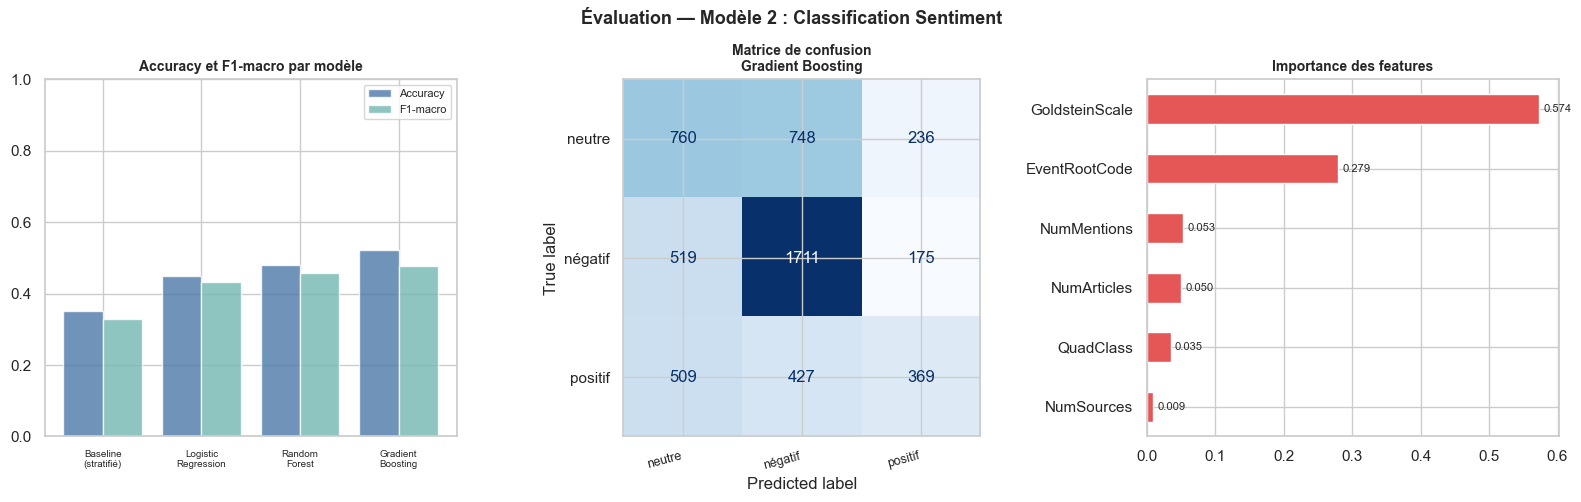


 Interprétation :
   Accuracy  : 0.521 → 52.1% des événements correctement classés
   F1-macro  : 0.477 → performance équilibrée sur les 3 classes
   La matrice de confusion révèle sur quelle classe le modèle
   commet le plus d'erreurs.


In [12]:
# ── Rapport complet sur le meilleur modèle ────────────────────────────────────
best_clf_pipeline = clf_results[best_clf_name]['pipeline']
y_pred_best = clf_results[best_clf_name]['y_pred']

print(f"\nRapport de classification — {best_clf_name} :")
print(classification_report(
    yc_test_enc, y_pred_best,
    target_names=le.classes_
))

# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Comparaison accuracy + F1
names_clf = list(clf_results.keys())
accs = [clf_results[n]['accuracy']  for n in names_clf]
f1s  = [clf_results[n]['f1_macro']  for n in names_clf]

x = np.arange(len(names_clf))
axes[0].bar(x - 0.2, accs, 0.4, label='Accuracy', color='#4C78A8', alpha=0.8)
axes[0].bar(x + 0.2, f1s,  0.4, label='F1-macro',  color='#72B7B2', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' ', '\n') for n in names_clf], fontsize=7)
axes[0].set_title('Accuracy et F1-macro par modèle', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

# Matrice de confusion
cm = confusion_matrix(yc_test_enc, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Matrice de confusion\n{best_clf_name}',
                  fontsize=10, fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=9)

# Importance des features
model_step = best_clf_pipeline.named_steps['model']
if hasattr(model_step, 'feature_importances_'):
    feat_imp = pd.Series(
        model_step.feature_importances_, index=FEATURES_FINAL
    ).sort_values()
    feat_imp.plot(kind='barh', ax=axes[2], color='#E45756')
    axes[2].set_title('Importance des features', fontsize=10, fontweight='bold')
    axes[2].bar_label(axes[2].containers[0], fmt='%.3f', padding=3, fontsize=8)
elif hasattr(model_step, 'coef_'):
    coef_df = pd.DataFrame(
        model_step.coef_, columns=FEATURES_FINAL, index=le.classes_
    )
    coef_df.T.plot(kind='bar', ax=axes[2])
    axes[2].set_title('Coefficients par classe', fontsize=10, fontweight='bold')
    axes[2].set_xticklabels(FEATURES_FINAL, rotation=30, ha='right', fontsize=8)

plt.suptitle('Évaluation — Modèle 2 : Classification Sentiment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_acc = clf_results[best_clf_name]['accuracy']
best_f1  = clf_results[best_clf_name]['f1_macro']
print(f"\n Interprétation :")
print(f"   Accuracy  : {best_acc:.3f} → {best_acc*100:.1f}% des événements correctement classés")
print(f"   F1-macro  : {best_f1:.3f} → performance équilibrée sur les 3 classes")
print(f"   La matrice de confusion révèle sur quelle classe le modèle")
print(f"   commet le plus d'erreurs.")


In [13]:
# ── Sauvegarde du modèle de classification ────────────────────────────────────
clf_save_path = MODELS_DIR / 'classification_sentiment.pkl'

save_obj_clf = {
    'model_name':    best_clf_name,
    'pipeline':      best_clf_pipeline,
    'label_encoder': le,
    'features':      FEATURES_FINAL,
    'target':        TARGET_CLF,
    'classes':       list(le.classes_),
    'seuils':        {'negatif': SEUIL_NEG, 'positif': SEUIL_POS},
    'metrics': {
        'accuracy': clf_results[best_clf_name]['accuracy'],
        'f1_macro': clf_results[best_clf_name]['f1_macro'],
    },
}

with open(clf_save_path, 'wb') as f:
    pickle.dump(save_obj_clf, f)

print(f"Modèle de classification sauvegardé : {clf_save_path}")
print(f"   Modèle   : {best_clf_name}")
print(f"   Accuracy : {save_obj_clf['metrics']['accuracy']:.3f}")
print(f"   F1-macro : {save_obj_clf['metrics']['f1_macro']:.3f}")
print(f"   Classes  : {save_obj_clf['classes']}")

# Vérification — rechargement
with open(clf_save_path, 'rb') as f:
    loaded_clf = pickle.load(f)

test_pred_labels = loaded_clf['label_encoder'].inverse_transform(
    loaded_clf['pipeline'].predict(X_test[:5])
)
print(f"\n✅ Vérification rechargement OK")
print(f"   5 prédictions test : {test_pred_labels}")


Modèle de classification sauvegardé : ..\models\sentiment_analysis\classification_sentiment.pkl
   Modèle   : Gradient Boosting
   Accuracy : 0.521
   F1-macro : 0.477
   Classes  : ['neutre', 'négatif', 'positif']

✅ Vérification rechargement OK
   5 prédictions test : ['neutre' 'négatif' 'neutre' 'neutre' 'négatif']


## 5. Exemple d'inférence — Comment utiliser les modèles

Cette section montre comment charger les modèles sauvegardés
et les utiliser pour prédire le sentiment d'un nouvel événement.
C'est ce que le dashboard Streamlit appellera.


In [15]:
# ── Exemple d'utilisation des modèles sauvegardés ────────────────────────────
print("=" * 60)
print("EXEMPLE D'INFÉRENCE")
print("=" * 60)

# Charger les deux modèles
with open(MODELS_DIR / 'regression_avgtone.pkl', 'rb') as f:
    reg_loaded = pickle.load(f)

with open(MODELS_DIR / 'classification_sentiment.pkl', 'rb') as f:
    clf_loaded = pickle.load(f)

# Simuler un nouvel événement
nouvel_evenement = pd.DataFrame([{
    'GoldsteinScale': -5.0,   # événement négatif
    'NumMentions':    25,
    'NumSources':     8,
    'NumArticles':    12,
    'QuadClass':      4,       # conflit matériel
    'EventRootCode':  18,      # attaques / agressions
}])[reg_loaded['features']]

tone_predit   = reg_loaded['pipeline'].predict(nouvel_evenement)[0]
sentiment_enc = clf_loaded['pipeline'].predict(nouvel_evenement)[0]
sentiment_label = clf_loaded['label_encoder'].inverse_transform([sentiment_enc])[0]

print(f"\nNouvel événement :")
print(f"  GoldsteinScale = -5.0 (conflit matériel)")
print(f"  NumMentions = 25, NumSources = 8")
print(f"\nPrédictions :")
print(f"  Modèle 1 — AvgTone prédit   : {tone_predit:.2f}")
print(f"  Modèle 2 — Sentiment prédit : {sentiment_label.upper()}")

# Tester aussi un événement positif
evenement_positif = pd.DataFrame([{
    'GoldsteinScale': 7.0,
    'NumMentions':    15,
    'NumSources':     6,
    'NumArticles':    8,
    'QuadClass':      2,
    'EventRootCode':  6,
}])[reg_loaded['features']]

tone_pos   = reg_loaded['pipeline'].predict(evenement_positif)[0]
sent_pos   = clf_loaded['label_encoder'].inverse_transform(
    clf_loaded['pipeline'].predict(evenement_positif)
)[0]

print(f"\nÉvénement coopératif (Goldstein=+7) :")
print(f"  Modèle 1 — AvgTone prédit   : {tone_pos:.2f}")
print(f"  Modèle 2 — Sentiment prédit : {sent_pos.upper()}")


EXEMPLE D'INFÉRENCE

Nouvel événement :
  GoldsteinScale = -5.0 (conflit matériel)
  NumMentions = 25, NumSources = 8

Prédictions :
  Modèle 1 — AvgTone prédit   : -6.71
  Modèle 2 — Sentiment prédit : NÉGATIF

Événement coopératif (Goldstein=+7) :
  Modèle 1 — AvgTone prédit   : -2.86
  Modèle 2 — Sentiment prédit : NÉGATIF


## 6. Synthèse et prochaines étapes

### Résultats v1 

| Modèle | Algorithme | Métrique principale | Valeur |
|--------|-----------|---------------------|--------|
| Régression AvgTone | Gradient Boosting | R² | O.215 |
| Classification Sentiment | Gradient Boosting | F1-macro | O,477 |

### Fichiers sauvegardés

```
models/sentiment_analysis/
├── regression_avgtone.pkl        ← prédiction valeur tone
└── classification_sentiment.pkl  ← prédiction positif/neutre/négatif
```

### Limites de la v1

- Les features sont **purement numériques** — le contenu textuel des articles
  n'est pas encore exploité
- Un R² faible est attendu : le tone dépend fortement du texte
- Les seuils positif/neutre/négatif sont fixés à ±2 — ils peuvent être affinés

### Prochaines étapes 

**NLP HuggingFace** — On pourrait utiliser un modèle pré-entraîné HuggingFace pour analyser le sentiment du texte des articles (GKG)

